In [1]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/My Drive/Skripsi/Datasheet/unlabeled_dataset.csv'

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10051899 entries, 0 to 10051898
Data columns (total 24 columns):
 #   Column       Dtype  
---  ------       -----  
 0   Unnamed: 0   int64  
 1   dt           float64
 2   switch       int64  
 3   src          object 
 4   dst          object 
 5   pktcount     int64  
 6   bytecount    int64  
 7   dur          float64
 8   dur_nsec     int64  
 9   tot_dur      float64
 10  flows        int64  
 11  packetins    int64  
 12  pktperflow   float64
 13  byteperflow  float64
 14  pktrate      float64
 15  Pairflow     int64  
 16  Protocol     object 
 17  port_no      int64  
 18  tx_bytes     int64  
 19  rx_bytes     int64  
 20  tx_kbps      float64
 21  rx_kbps      float64
 22  tot_kbps     float64
 23  label        float64
dtypes: float64(10), int64(11), object(3)
memory usage: 1.8+ GB


In [3]:
df.describe()

,Unnamed: 0,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,...,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,1.005190e+07,1.005190e+07,10051899.0,1.005190e+07,1.005190e+07,1.005190e+07,10051899.0,1.005190e+07,1.005190e+07,1.005190e+07,...,1.005190e+07,1.005190e+07,1.005190e+07,1.005190e+07,10051899.0,1.005190e+07,10051899.0,1.005190e+07,1.005190e+07,0.0
mean,5.025949e+06,4.144375e-02,0.0,2.100565e+05,2.498282e+08,4.144375e-02,0.0,4.144375e-02,7.443994e+02,2.093121e+05,...,4.555259e+06,1.244182e-04,7.350290e+02,1.829326e+04,0.0,2.498282e+08,0.0,8.092810e+10,8.092810e+10,NaN
std,2.901733e+06,3.037068e-01,0.0,1.258329e+05,1.437988e+08,3.037068e-01,0.0,3.037068e-01,1.916641e+03,1.249003e+05,...,4.280375e+06,7.455463e-05,1.891242e+03,2.173770e+04,0.0,1.437988e+08,0.0,2.332175e+11,2.332175e+11,NaN
min,0.000000e+00,-5.900000e-05,0.0,1.000000e+00,6.800000e+01,-5.900000e-05,0.0,-5.900000e-05,1.000000e+00,0.000000e+00,...,6.800000e+01,5.877329e-10,1.000000e+00,7.000000e+00,0.0,6.800000e+01,0.0,0.000000e+00,0.000000e+00,NaN
25%,2.512974e+06,1.200000e-05,0.0,1.013150e+05,1.252747e+08,1.200000e-05,0.0,1.200000e-05,3.000000e+01,1.012740e+05,...,1.555728e+06,6.000089e-05,3.000000e+01,4.430000e+02,0.0,1.252747e+08,0.0,9.946737e+08,9.946737e+08,NaN
50%,5.025949e+06,4.400000e-05,0.0,2.076280e+05,2.517923e+08,4.400000e-05,0.0,4.400000e-05,4.600000e+01,2.074280e+05,...,4.078439e+06,1.229611e-04,4.600000e+01,4.430000e+02,0.0,2.517923e+08,0.0,1.168052e+10,1.168052e+10,NaN
75%,7.538924e+06,4.680000e-04,0.0,3.138510e+05,3.765408e+08,4.680000e-04,0.0,4.680000e-04,8.000000e+01,3.128700e+05,...,6.510099e+06,1.858650e-04,8.000000e+01,3.873000e+04,0.0,3.765408e+08,0.0,9.900904e+10,9.900904e+10,NaN
max,1.005190e+07,5.172620e+01,0.0,5.383070e+05,4.948971e+08,5.172620e+01,0.0,5.172620e+01,1.252100e+04,5.313730e+05,...,3.391395e+07,3.191955e-04,1.243700e+04,6.553200e+04,0.0,4.948971e+08,0.0,3.957698e+12,3.957698e+12,NaN


In [4]:
df.isnull().sum()

,0
Unnamed: 0,0
dt,0
switch,0
src,0
dst,0
pktcount,0
bytecount,0
dur,0
dur_nsec,0
tot_dur,0


In [5]:
df.columns

Index(['Unnamed: 0', 'dt', 'switch', 'src', 'dst', 'pktcount', 'bytecount',
       'dur', 'dur_nsec', 'tot_dur', 'flows', 'packetins', 'pktperflow',
       'byteperflow', 'pktrate', 'Pairflow', 'Protocol', 'port_no', 'tx_bytes',
       'rx_bytes', 'tx_kbps', 'rx_kbps', 'tot_kbps', 'label'],
      dtype='object')

In [6]:
df.drop(columns='Unnamed: 0', inplace=True)

**Preprocessing**

In [7]:
Features = ['dt', 'dur', 'tot_dur', 'pktrate', 'port_no', 'rx_kbps', 'tot_kbps']
X = df[Features]

In [20]:
X['port_no'].value_counts(ascending=True)

,count
port_no,
33472,1
39627,1
44898,1
56414,1
35005,1
...,...
9090,171735
22,276320
38416,349815


In [9]:
kolom_negatif = ['dt', 'dur', 'tot_dur']
X = X[(X[kolom_negatif]>= 0).all(axis=1)]

In [10]:
print(X.shape)
print(df.shape)

(10051310, 7)
(10051899, 23)


In [11]:
df = df.loc[X.index]

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['dt','dur','tot_dur','pktrate','rx_kbps','tot_kbps']
num_tranform = scaler

In [57]:
import numpy as np

np.random.seed(42)
sample_indices = np.random.choice(X.shape[0], size=1000000, replace=False)
X_sample = X.iloc[sample_indices]

**Training**

In [58]:
from sklearn.ensemble import IsolationForest

model_Iforest = IsolationForest(
    n_estimators = 100,
    contamination='auto',
    random_state=42,
    n_jobs = -1
)

In [59]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num', num_tranform, num_features)
], remainder = 'passthrough')

In [60]:
from sklearn.pipeline import Pipeline

iForest_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_Iforest)
])

In [61]:
label_mentah = iForest_pipeline.fit_predict(X_sample)

In [62]:
label = np.where(label_mentah == 1, 0, 1)

In [63]:
unik, jumlah = np.unique(label, return_counts=True)
distribusi = dict(zip(unik, jumlah))
print(f"Cluster 0 (Normal) : {distribusi.get(0,0):,} baris")
print(f"Cluster 1 (Anomali) : {distribusi.get(1,0):,} baris")

Cluster 0 (Normal) : 924,070 baris
Cluster 1 (Anomali) : 75,930 baris


**EVALUATE**

In [68]:
np.random.seed(42)
eval_indices = np.random.choice(len(X_sample), size=50000, replace=False)

In [70]:
X_eval = X_sample.iloc[eval_indices]
label_eval = label[eval_indices]

In [71]:
X_eval_scaled = iForest_pipeline.named_steps['preprocessor'].transform(X_eval)

In [74]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

if len(np.unique(label_eval)) > 1:
  print("Menghitung Calinski-Harabasz Score dan Davies-Bouldin Score")
  db_score = davies_bouldin_score(X_eval_scaled, label_eval)
  ch_score = calinski_harabasz_score(X_eval_scaled, label_eval)

  print("Menghitung Silhouette Score")
  sil_score = silhouette_score(X_eval_scaled, label_eval)

  print("Evaluasi Metrik")
  print(f"Silhouette Score : {sil_score:.4f}")
  print(f"Davies-Bouldin Score : {db_score:.4f}")
  print(f"Calinski-Harabasz Score : {ch_score:.4f}")

else:
  print("Evaluasi gagal: Model hanya mendeteksi 1 cluster")

Menghitung Calinski-Harabasz Score dan Davies-Bouldin Score
Menghitung Silhouette Score
Evaluasi Metrik
Silhouette Score : 0.1392
Davies-Bouldin Score : 3.2818
Calinski-Harabasz Score : 1165.5934


In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_eval_scaled)

In [77]:
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3'])
df_pca['cluster'] = label_eval
df_pca['cluster'] = df_pca['cluster'].astype(str)

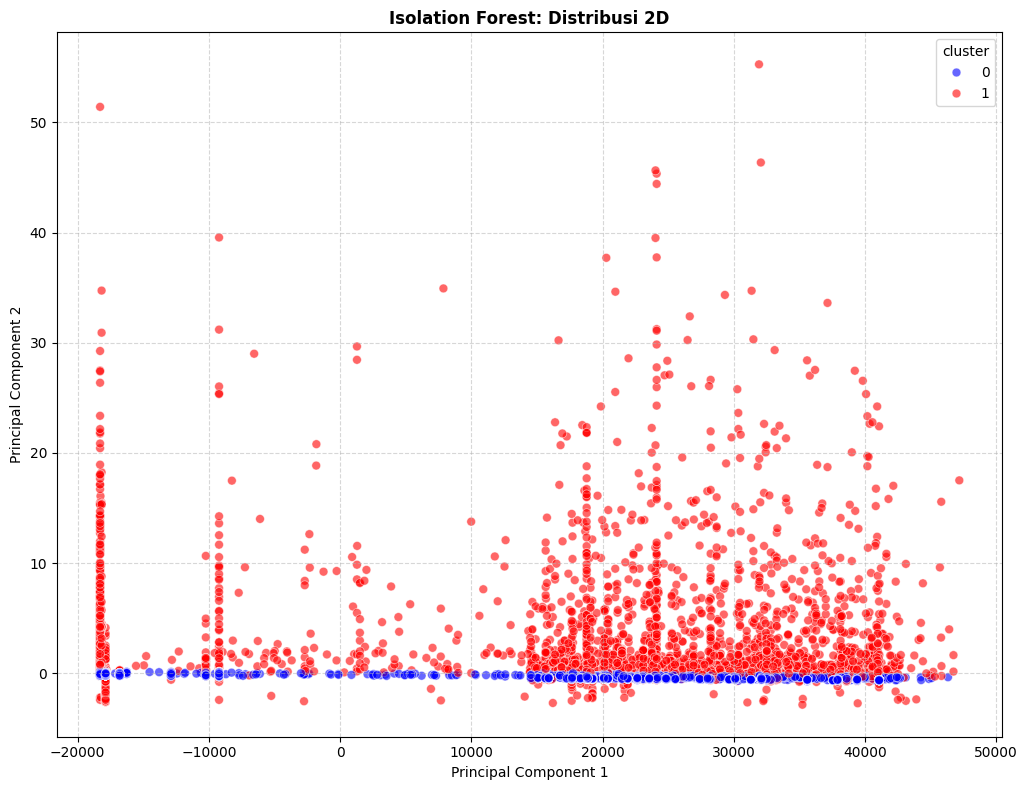

In [79]:
warna_pallete = {'0':'blue','1':'red'}

fig_1 = plt.figure(figsize=(20,8))
ax1 = fig_1.add_subplot(121)
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=df_pca,
    palette=warna_pallete,
    alpha=0.6,
    s=40,
    ax=ax1
)
ax1.set_title('Isolation Forest: Distribusi 2D', fontsize=12, fontweight='bold')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True,linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

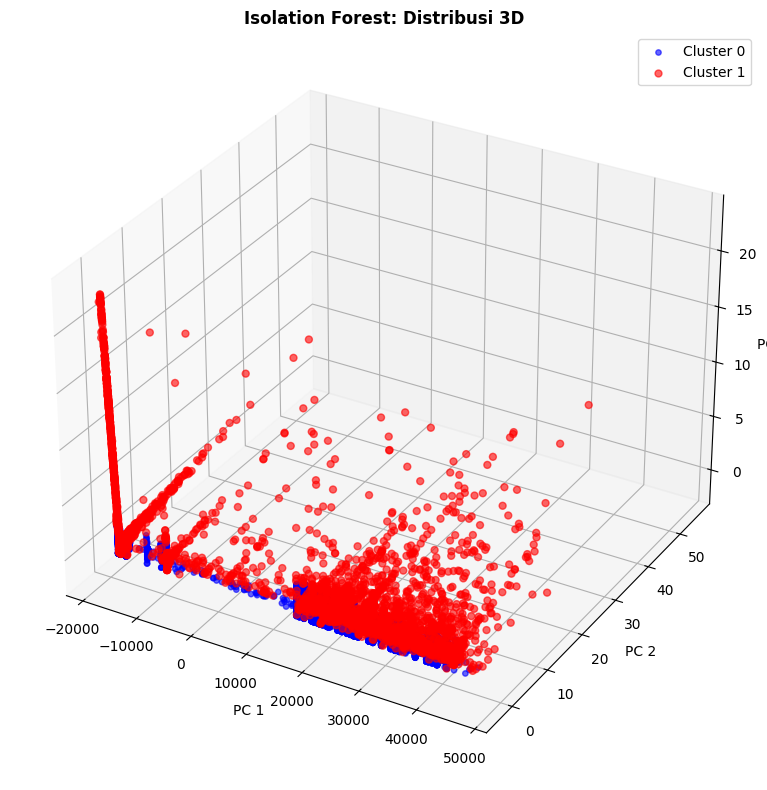

In [82]:
fig_2 = plt.figure(figsize=(20,8))
ax2 = fig_2.add_subplot(122, projection='3d')
for cluster_id in df_pca['cluster'].unique():
  subset = df_pca[df_pca['cluster'] == cluster_id]

  # Pengaturan ukuran dan urutan tumpukan agar Anomali (1) lebih terlihat
  if cluster_id == '1':
    ukuran = 25
    z_order = 5
  else:
    ukuran = 15
    z_order = 1 # Normal di lapisan bawah

  ax2.scatter(
      subset['PC1'], subset['PC2'], subset['PC3'],
      label = f'Cluster {cluster_id}',
      c=warna_pallete.get(cluster_id, 'gray'),
      alpha=0.6,
      s=ukuran,
      zorder=z_order
  )
ax2.set_title('Isolation Forest: Distribusi 3D', fontsize=12, fontweight='bold')
ax2.set_xlabel('PC 1'),
ax2.set_ylabel('PC 2'),
ax2.set_zlabel('PC 3'),
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [83]:
variance_ratio = pca.explained_variance_ratio_.sum()*100
print(f"\nTotal informasi yang dipertahankan oleh 3 PC:{variance_ratio:.2f}%")


Total informasi yang dipertahankan oleh 3 PC:100.00%


/tmp/ipykernel_2121/381529220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=label, y=X_sample['pktrate'],palette={'0':'blue', '1':'red'})


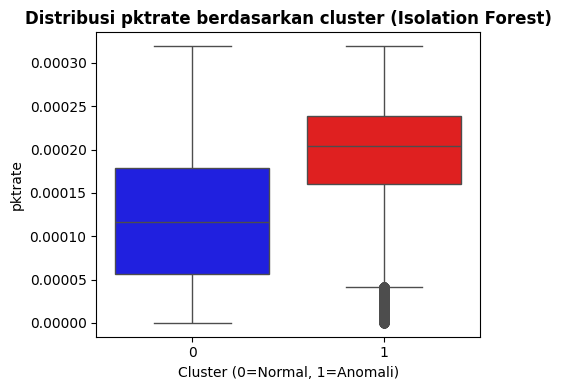

In [85]:
plt.figure(figsize=(5,4))
sns.boxplot(x=label, y=X_sample['pktrate'],palette={'0':'blue', '1':'red'})
plt.title('Distribusi pktrate berdasarkan cluster (Isolation Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster (0=Normal, 1=Anomali)')
plt.ylabel('pktrate')
plt.tight_layout()
plt.show()

In [86]:
from google.colab import files
import joblib

joblib.dump(iForest_pipeline, 'iForest_Model.joblib')
files.download('iForest_Model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>